In [138]:
import geopandas as gpd
from dem_stitcher.geojson_io import read_geojson_gzip
from rasterio.crs import CRS
import matplotlib.pyplot as plt
import contextily as ctx
import pandas as pd
from shapely import STRtree
from tqdm import tqdm
import numpy as np
from shapely import STRtree

# Land

## Natural Earth

In [139]:
# land_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_land.json'
# df_ne_land = gpd.read_file(land_url)

In [140]:
# minor_islands_url = 'https://raw.githubusercontent.com/martynafford/natural-earth-geojson/refs/heads/master/10m/physical/ne_10m_minor_islands.json'
# df_ne_mi = gpd.read_file(minor_islands_url)

In [141]:
# df_ne_all_land = pd.concat([df_ne_mi, df_ne_land])
# land_geo = df_ne_all_land.geometry.union_all().buffer(.02)

## UMD Land Mask

In [5]:
%%time

land_geo = gpd.read_parquet('land_mask_umd_union.parquet').geometry.union_all(method='disjoint_subset')

CPU times: user 25.8 s, sys: 5.3 s, total: 31.1 s
Wall time: 31.5 s


In [6]:
# %%time

# land_geo = gpd.read_parquet('land_mask_umd_union.parquet').geometry.union_all(method='coverage')

# MGRS

In [7]:
df_mgrs = gpd.read_parquet('../N_hls_tiles/mgrs.parquet')
df_mgrs = df_mgrs.rename(columns={'tile_id': 'mgrs_tile_id'})
print('Total MGRS tiles: ', df_mgrs.shape[0])
df_mgrs.head()

Total MGRS tiles:  56686


,mgrs_tile_id,utm_epsg,utm_wkt,geometry
0,01CCV,32701,"MULTIPOLYGON(((300000 2000020,300000 1890220,4...","MULTIPOLYGON (((-179.62744 -72.0814, -179.7751..."
1,01CDH,32701,"MULTIPOLYGON(((399960 800020,399960 690220,509...","MULTIPOLYGON (((-176.29744 -82.85185, -176.185..."
2,01CDJ,32701,"MULTIPOLYGON(((399960 900040,399960 790240,509...","MULTIPOLYGON (((-176.37525 -81.95591, -176.288..."
3,01CDK,32701,"MULTIPOLYGON(((399960 1000000,399960 890200,50...","MULTIPOLYGON (((-176.43739 -81.06046, -176.368..."
4,01CDL,32701,"MULTIPOLYGON(((399960 1100020,399960 990220,50...","MULTIPOLYGON (((-176.4882 -80.16441, -176.4318..."


In [8]:
with open('../R_mgrs_burst_lookup/dist_hls_tiles.txt') as f:
    hls_tiles = f.readlines()
hls_tiles = list(map(lambda tile: tile.strip(), hls_tiles))
hls_tiles[:3]

['01RGJ', '01RFL', '01REL']

In [9]:
idxs_dist = df_mgrs.mgrs_tile_id.isin(hls_tiles)
idxs_dist[:3]

0    False
1    False
2    False
Name: mgrs_tile_id, dtype: bool

In [10]:
df_mgrs_dist_hls = df_mgrs[idxs_dist].reset_index(drop=True)
n = df_mgrs_dist_hls.shape[0]
f'Total MGRS tiles over land: {n}'

'Total MGRS tiles over land: 19043'

<Axes: >

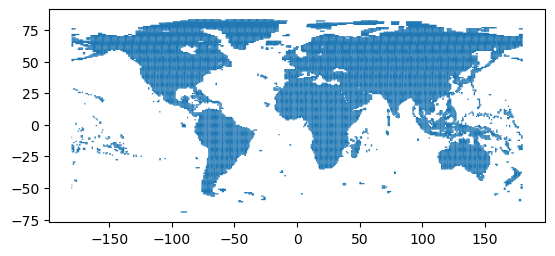

In [11]:
df_mgrs_dist_hls.plot()

# JPL Bursts

In [142]:
df_burst = gpd.read_file('../Zb_update_burst_table/opera-s1-disp-0.12.0.gpkg')
# Maybe I may have duplicated rows with burst? Not sure, but drop duplicates ensures we have 1 row for each jpl_burst_id
df_burst = df_burst.drop_duplicates(subset='burst_id_jpl', keep='first').reset_index(drop=True)
df_burst.head()

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'opera-s1-disp-0.12.0.gpkg': 'burst_id_map' (default), 'frames', 'frames_bursts', 'metadata'. Specify layer parameter to avoid this warning.
  result = read_func(


,burst_id,subswath_name,relative_orbit_number,time_from_anx_sec,orbit_pass,burst_id_jpl,epsg,is_north_america,xmin,ymin,xmax,ymax,geometry
0,1,IW1,1,2.301015,ASCENDING,t001_000001_iw1,32631,False,531360,78240,630690,128280,"MULTIPOLYGON Z (((3.36758 0.75322 0, 3.763 0.8..."
1,1,IW2,1,3.133218,ASCENDING,t001_000001_iw2,32631,False,612180,102660,715320,152370,"MULTIPOLYGON Z (((4.09178 0.97402 0, 4.50253 1..."
2,1,IW3,1,4.211255,ASCENDING,t001_000001_iw3,32631,False,696870,126810,789960,175590,"MULTIPOLYGON Z (((4.85545 1.192 0, 5.21485 1.2..."
3,2,IW1,1,5.059288,ASCENDING,t001_000002_iw1,32631,False,527460,96690,626820,146730,"MULTIPOLYGON Z (((3.33269 0.92005 0, 3.7281 1...."
4,2,IW2,1,5.891491,ASCENDING,t001_000002_iw2,32631,False,608280,121080,711450,170760,"MULTIPOLYGON Z (((4.0569 1.14071 0, 4.46766 1...."


In [143]:
burst_geos = df_burst.geometry.tolist()
burst_id = df_burst.burst_id_jpl.str.upper().str.replace('_', '-').tolist()
track_number = df_burst.burst_id_jpl.map(lambda burst_id: int(burst_id.split('_')[0][1:]))
orbit_pass = df_burst.orbit_pass.tolist()

In [144]:
df_burst_final_all = gpd.GeoDataFrame({'jpl_burst_id': burst_id,
                                   'orbit_pass': orbit_pass,
                                   'track_number': track_number,
                                   #'is_land': df_burst.is_land.tolist()
                                  },
                                   geometry=burst_geos,
                                   crs=CRS.from_epsg(4326))
df_burst_final_all.head()

,jpl_burst_id,orbit_pass,track_number,geometry
0,T001-000001-IW1,ASCENDING,1,"MULTIPOLYGON Z (((3.36758 0.75322 0, 3.763 0.8..."
1,T001-000001-IW2,ASCENDING,1,"MULTIPOLYGON Z (((4.09178 0.97402 0, 4.50253 1..."
2,T001-000001-IW3,ASCENDING,1,"MULTIPOLYGON Z (((4.85545 1.192 0, 5.21485 1.2..."
3,T001-000002-IW1,ASCENDING,1,"MULTIPOLYGON Z (((3.33269 0.92005 0, 3.7281 1...."
4,T001-000002-IW2,ASCENDING,1,"MULTIPOLYGON Z (((4.0569 1.14071 0, 4.46766 1...."


In [145]:
df_burst_final_all.to_parquet('jpl_burst_all.parquet', compression='zstd')

# Land Intersection Optional

In [15]:
%%time

if True:
    tree = STRtree(df_burst_final_all.geometry)
    idxs_land = tree.query(land_geo, predicate="intersects")
    df_burst_land = df_burst_final_all.iloc[idxs_land].copy()
    # Wonky indexing with STRtree
    df_burst_land = df_burst_land.sort_values(by='jpl_burst_id').reset_index(drop=True)
    print('land bursts', df_burst_land.shape[0])
    print('all bursts', df_burst_final_all.shape[0])
    df_burst_final_all = df_burst_land.copy()

land bursts 321272
all bursts 1127661
CPU times: user 1min 24s, sys: 3.32 s, total: 1min 27s
Wall time: 1min 28s


In [18]:
df_burst_final_all.head()

,jpl_burst_id,orbit_pass,track_number,geometry
0,T001-000025-IW3,ASCENDING,1,"MULTIPOLYGON Z (((4.02659 5.18854 0, 4.38755 5..."
1,T001-000027-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.95778 5.52153 0, 4.31898 5..."
2,T001-000030-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.85573 6.02123 0, 4.21726 6..."
3,T001-000031-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.82176 6.1878 0, 4.18341 6...."
4,T001-000032-IW2,ASCENDING,1,"MULTIPOLYGON Z (((3.01846 6.14155 0, 3.43161 6..."


# Serialize MGRS and Burst Data

In [16]:
df_burst_final_all.to_parquet('jpl_burst.parquet', compression='zstd')
df_mgrs_dist_hls.to_parquet('mgrs.parquet', compression='zstd')

# Multipolygons along Antimeridian

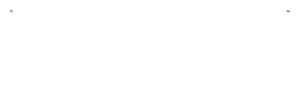

In [23]:
multi_geo = df_burst_final_all[df_burst_final_all.jpl_burst_id == 'T001-000683-IW2'].geometry.values[0]
multi_geo

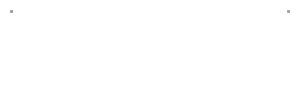

In [24]:
anti_meridian_tile_id = '01VCK'
df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].geometry.values[0]

# Spatial Join

Note we could have change `how='inner'` and removed the `na` accounting. But we wanted to see which HLS tiles were missing.

In [25]:
%%time

df_mgrs_burst = gpd.sjoin(df_mgrs_dist_hls, df_burst_final_all, how='left', predicate='intersects')
df_mgrs_burst = df_mgrs_burst.drop(columns='index_right').reset_index(drop=True)
df_mgrs_burst.head()

CPU times: user 1.16 s, sys: 158 ms, total: 1.31 s
Wall time: 1.32 s


,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330470-IW2,ASCENDING,154.0
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW3,DESCENDING,58.0
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123814-IW3,DESCENDING,58.0
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330472-IW2,ASCENDING,154.0
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T131-280611-IW2,DESCENDING,131.0


In [26]:
df_mgrs_burst[df_mgrs_burst.mgrs_tile_id == '01XDE']

,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
3161,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T016-032835-IW1,DESCENDING,16.0
3162,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T045-095126-IW2,DESCENDING,45.0
3163,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T168-359157-IW3,ASCENDING,168.0
3164,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T095-202360-IW2,ASCENDING,95.0
3165,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T124-264652-IW1,ASCENDING,124.0
3166,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T147-314215-IW3,DESCENDING,147.0
3167,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T118-251924-IW2,DESCENDING,118.0
3168,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T016-032834-IW1,DESCENDING,16.0
3169,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T022-045562-IW2,ASCENDING,22.0
3170,01XDE,32601,"MULTIPOLYGON(((399960 8500020,399960 8390220,5...","MULTIPOLYGON (((-176.62325 76.58075, -176.6484...",T168-359158-IW3,ASCENDING,168.0


In [27]:
df_mgrs_burst_f = df_mgrs_burst.dropna(subset=['jpl_burst_id']).reset_index(drop=True)
df_mgrs_burst_f.shape, df_mgrs_burst.shape

((1006812, 7), (1006844, 7))

We can explore the tiles that are in HLS but do not intersect with JPL Bursts.

In [28]:
f'Total MGRS tiles that do not intesect with jpl bursts: {df_mgrs_burst.jpl_burst_id.isnull().sum()}'

'Total MGRS tiles that do not intesect with jpl bursts: 32'

In [29]:
df_mgrs_burst[df_mgrs_burst.jpl_burst_id.isnull()]#.explore()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
3430,02RQN,32602,"MULTIPOLYGON(((699960 2800020,699960 2690220,8...","POLYGON ((-169.01378 25.30335, -169.02951 24.3...",NaN,NaN,NaN
3431,02RRN,32602,"MULTIPOLYGON(((799980 2800020,799980 2690220,9...","POLYGON ((-168.02115 25.28664, -168.04473 24.2...",NaN,NaN,NaN
14005,05LNJ,32705,"MULTIPOLYGON(((499980 8900020,499980 8790220,6...","POLYGON ((-153.00018 -9.95087, -153.00018 -10....",NaN,NaN,NaN
128731,15DWD,32715,"MULTIPOLYGON(((499980 2400040,499980 2290240,6...","POLYGON ((-93.00049 -68.51209, -93.00051 -69.4...",NaN,NaN,NaN
128732,15DXD,32715,"MULTIPOLYGON(((600000 2400040,600000 2290240,7...","POLYGON ((-90.55515 -68.49429, -90.4434 -69.47...",NaN,NaN,NaN
319775,23EMN,32723,"MULTIPOLYGON(((399960 3300040,399960 3190240,5...","POLYGON ((-46.81698 -60.42353, -46.87396 -61.4...",NaN,NaN,NaN
319776,23EMP,32723,"MULTIPOLYGON(((399960 3400000,399960 3290200,5...","POLYGON ((-46.76847 -59.5264, -46.82192 -60.51...",NaN,NaN,NaN
319777,23ENN,32723,"MULTIPOLYGON(((499980 3300040,499980 3190240,6...","POLYGON ((-45.00036 -60.43592, -45.00037 -61.4...",NaN,NaN,NaN
537368,36JZT,32736,"MULTIPOLYGON(((799980 7300000,799980 7190200,9...","POLYGON ((35.95732 -24.38454, 35.98101 -25.374...",NaN,NaN,NaN
565424,37GCH,32737,"MULTIPOLYGON(((300000 4800040,300000 4690240,4...","POLYGON ((36.37302 -46.92302, 36.32343 -47.909...",NaN,NaN,NaN


# Visualization/Explanation

## Looking at Burst Coverage over MGRS tiles - Known Edge Cases

### Lots of Tracks

In [30]:
tile_id_large_num_tracks = '48XVP' #df_mgrs_burst.mgrs_tile_id.sample(n=1, random_state=3).values[0]

tile_id_large_num_tracks

'48XVP'

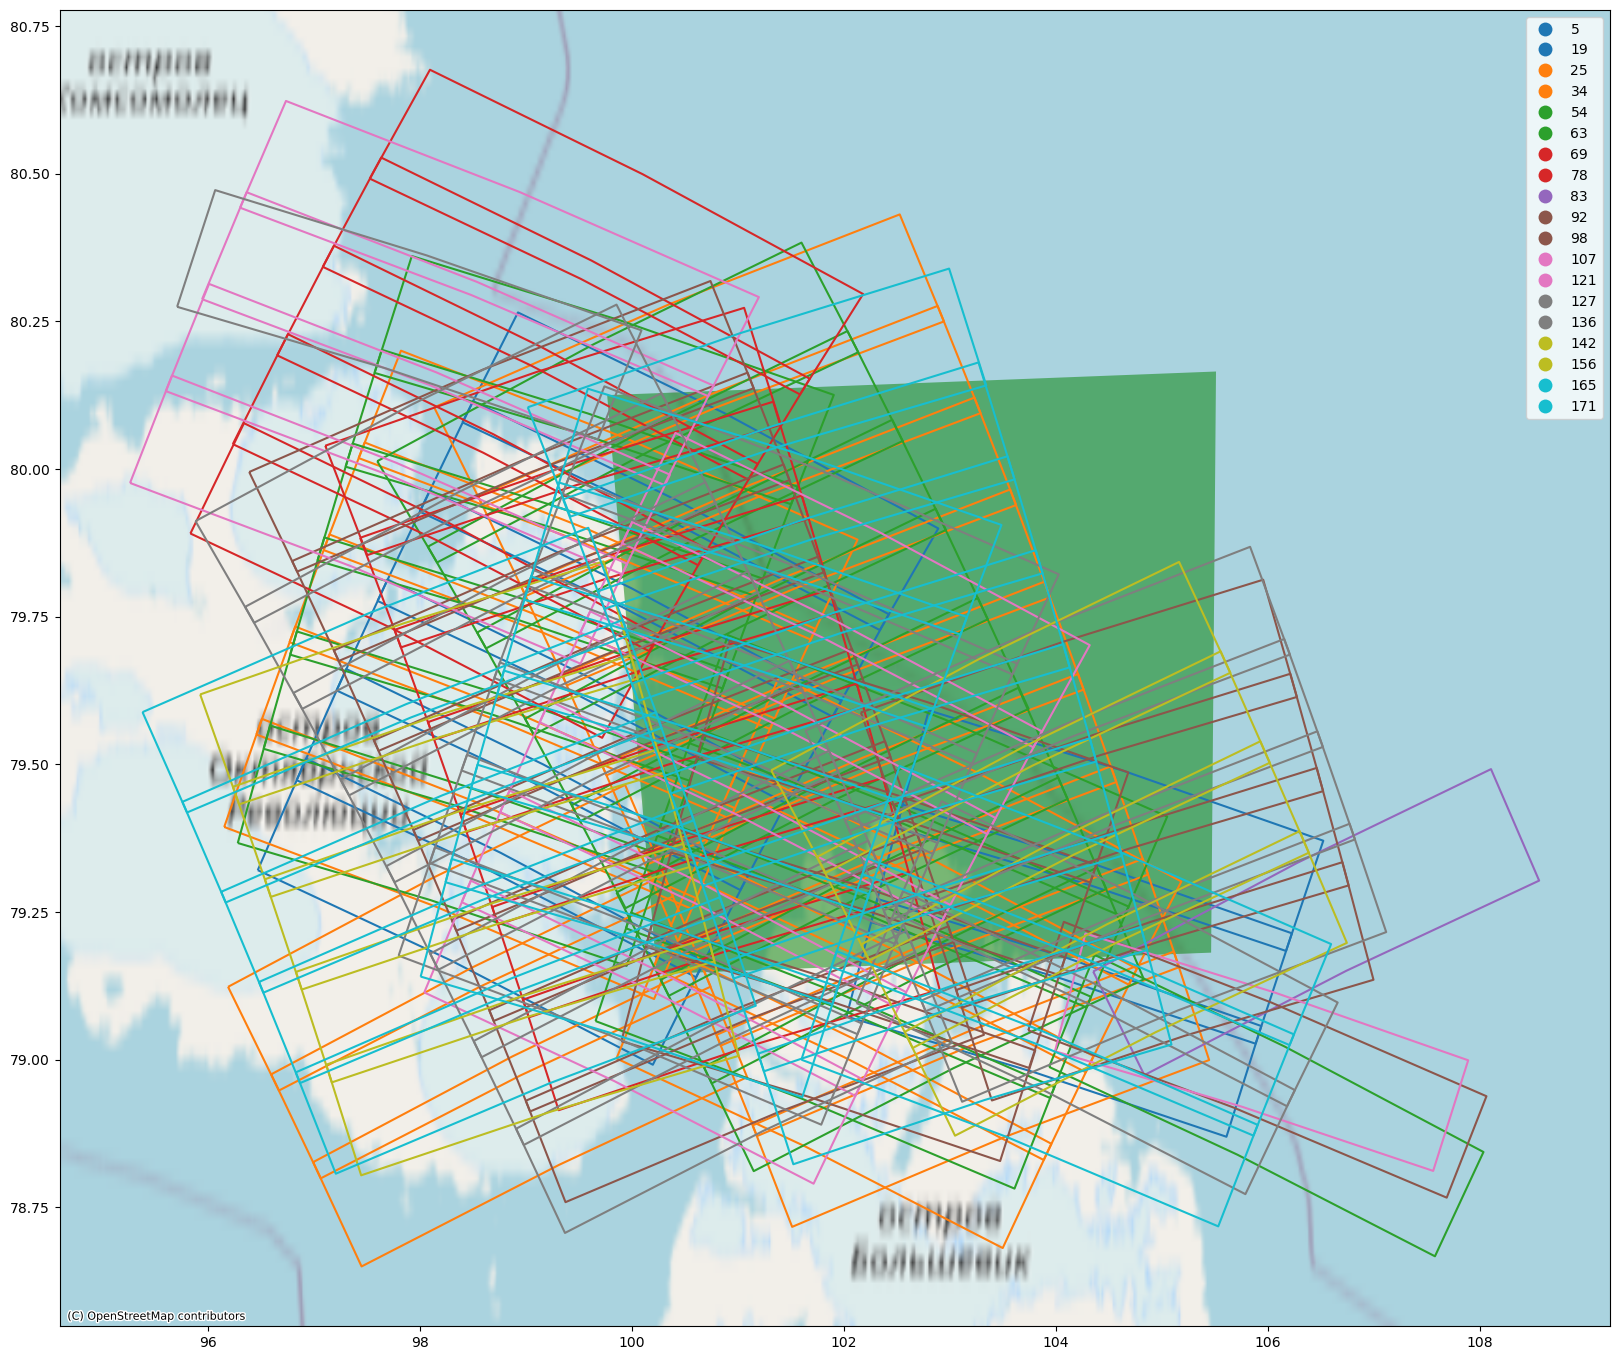

In [34]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == tile_id_large_num_tracks].reset_index(drop=True)
df_burst_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

Remember in these high lattidude areas, these all represent different data takes!

<Axes: >

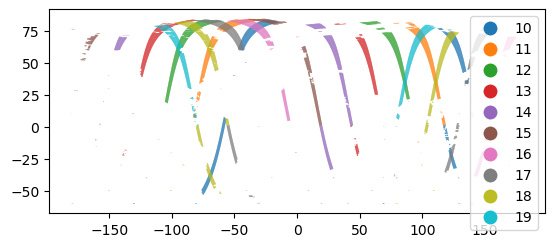

In [35]:
df_burst_final_all[df_burst_final_all['track_number'].isin(list(range(10, 20)))].plot(column='track_number', categorical=True, legend=True)

## With a Small Overlapping Burst

In [36]:
mgrs_id_with_small_burst_overlapping = '31QGE'

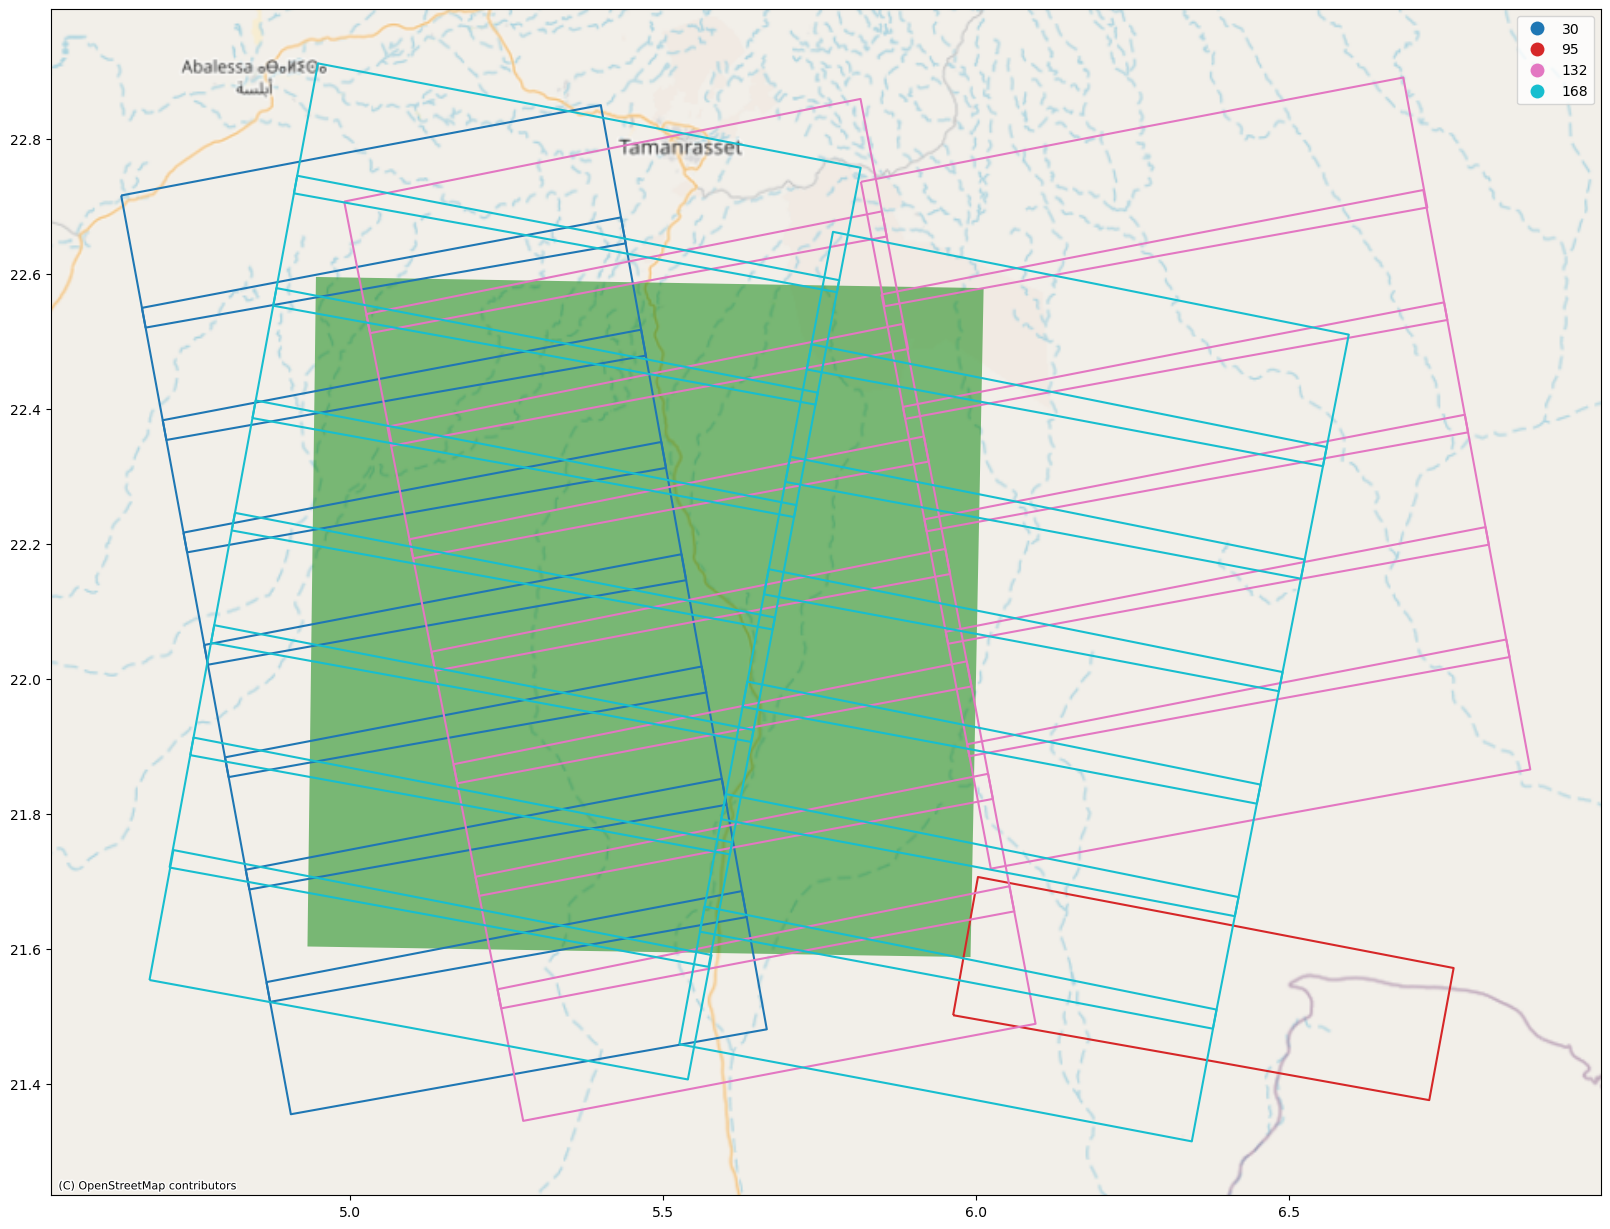

In [37]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_id_with_small_burst_overlapping].reset_index(drop=True)
df_burst_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Random

In [38]:
random_mgrs_tile_id = df_mgrs_burst_f.mgrs_tile_id.sample(n=1, random_state=40).values[0]
random_mgrs_tile_id

'37MEU'

In [39]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_mrgs_burst_subset.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,37MEU,32737,"MULTIPOLYGON(((499980 9900040,499980 9790240,6...","POLYGON ((38.99982 -0.90437, 38.99982 -1.89776...",T006-011829-IW1,DESCENDING,6.0
1,37MEU,32737,"MULTIPOLYGON(((499980 9900040,499980 9790240,6...","POLYGON ((38.99982 -0.90437, 38.99982 -1.89776...",T159-341504-IW1,ASCENDING,159.0
2,37MEU,32737,"MULTIPOLYGON(((499980 9900040,499980 9790240,6...","POLYGON ((38.99982 -0.90437, 38.99982 -1.89776...",T006-011829-IW2,DESCENDING,6.0
3,37MEU,32737,"MULTIPOLYGON(((499980 9900040,499980 9790240,6...","POLYGON ((38.99982 -0.90437, 38.99982 -1.89776...",T057-122413-IW3,ASCENDING,57.0
4,37MEU,32737,"MULTIPOLYGON(((499980 9900040,499980 9790240,6...","POLYGON ((38.99982 -0.90437, 38.99982 -1.89776...",T006-011829-IW3,DESCENDING,6.0


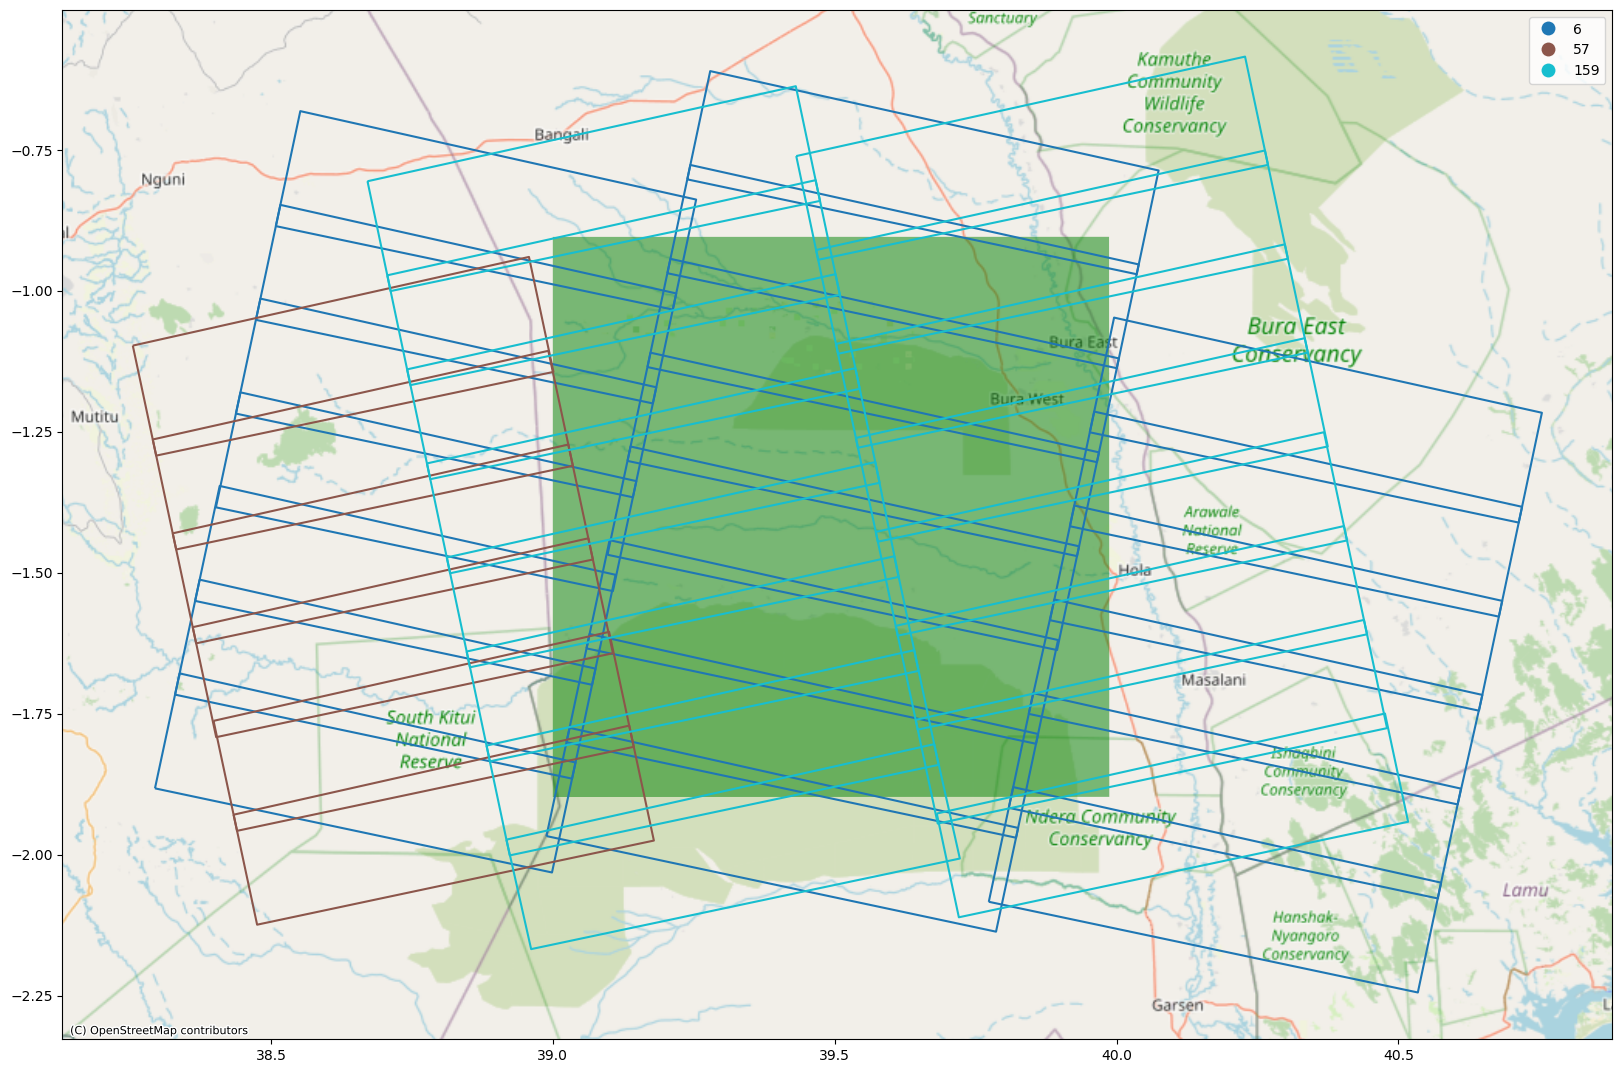

In [40]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == random_mgrs_tile_id].reset_index(drop=True)
df_burst_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

### Near Antimeridian

In [41]:
anti_meridian_tile_id = '01VCK'

<Axes: >

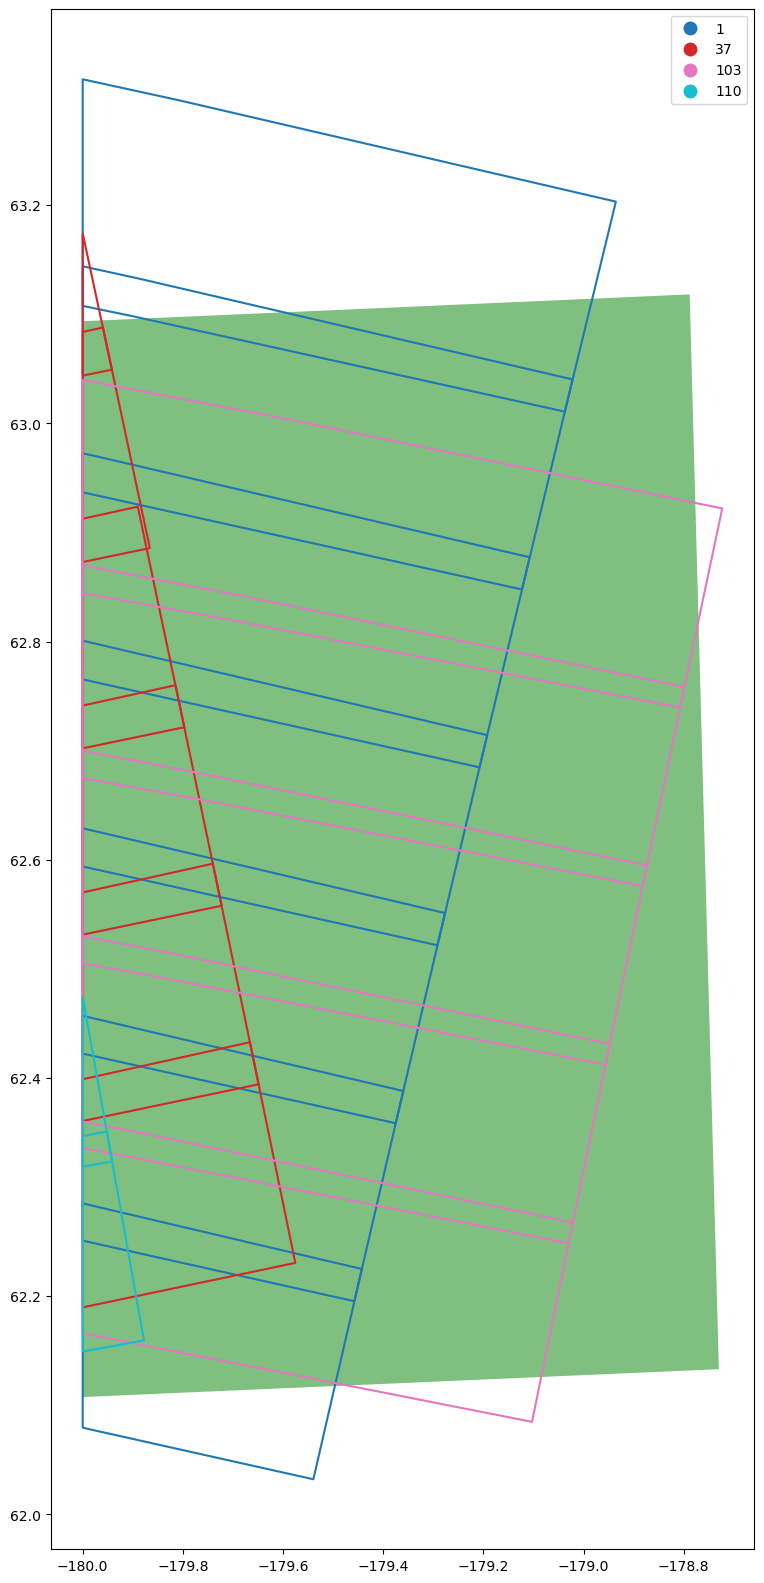

In [42]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == anti_meridian_tile_id].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == anti_meridian_tile_id].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_ids_subset)].explode(ignore_index=True).cx[:0, :].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)
# ctx.add_basemap(ax,
#                crs=df_mgrs_plot.crs.to_string(),
#                source=ctx.providers.OpenStreetMap.Mapnik
#               )

### Near Equator

In [43]:
mgrs_tile_id_near_eq = '22NFF'

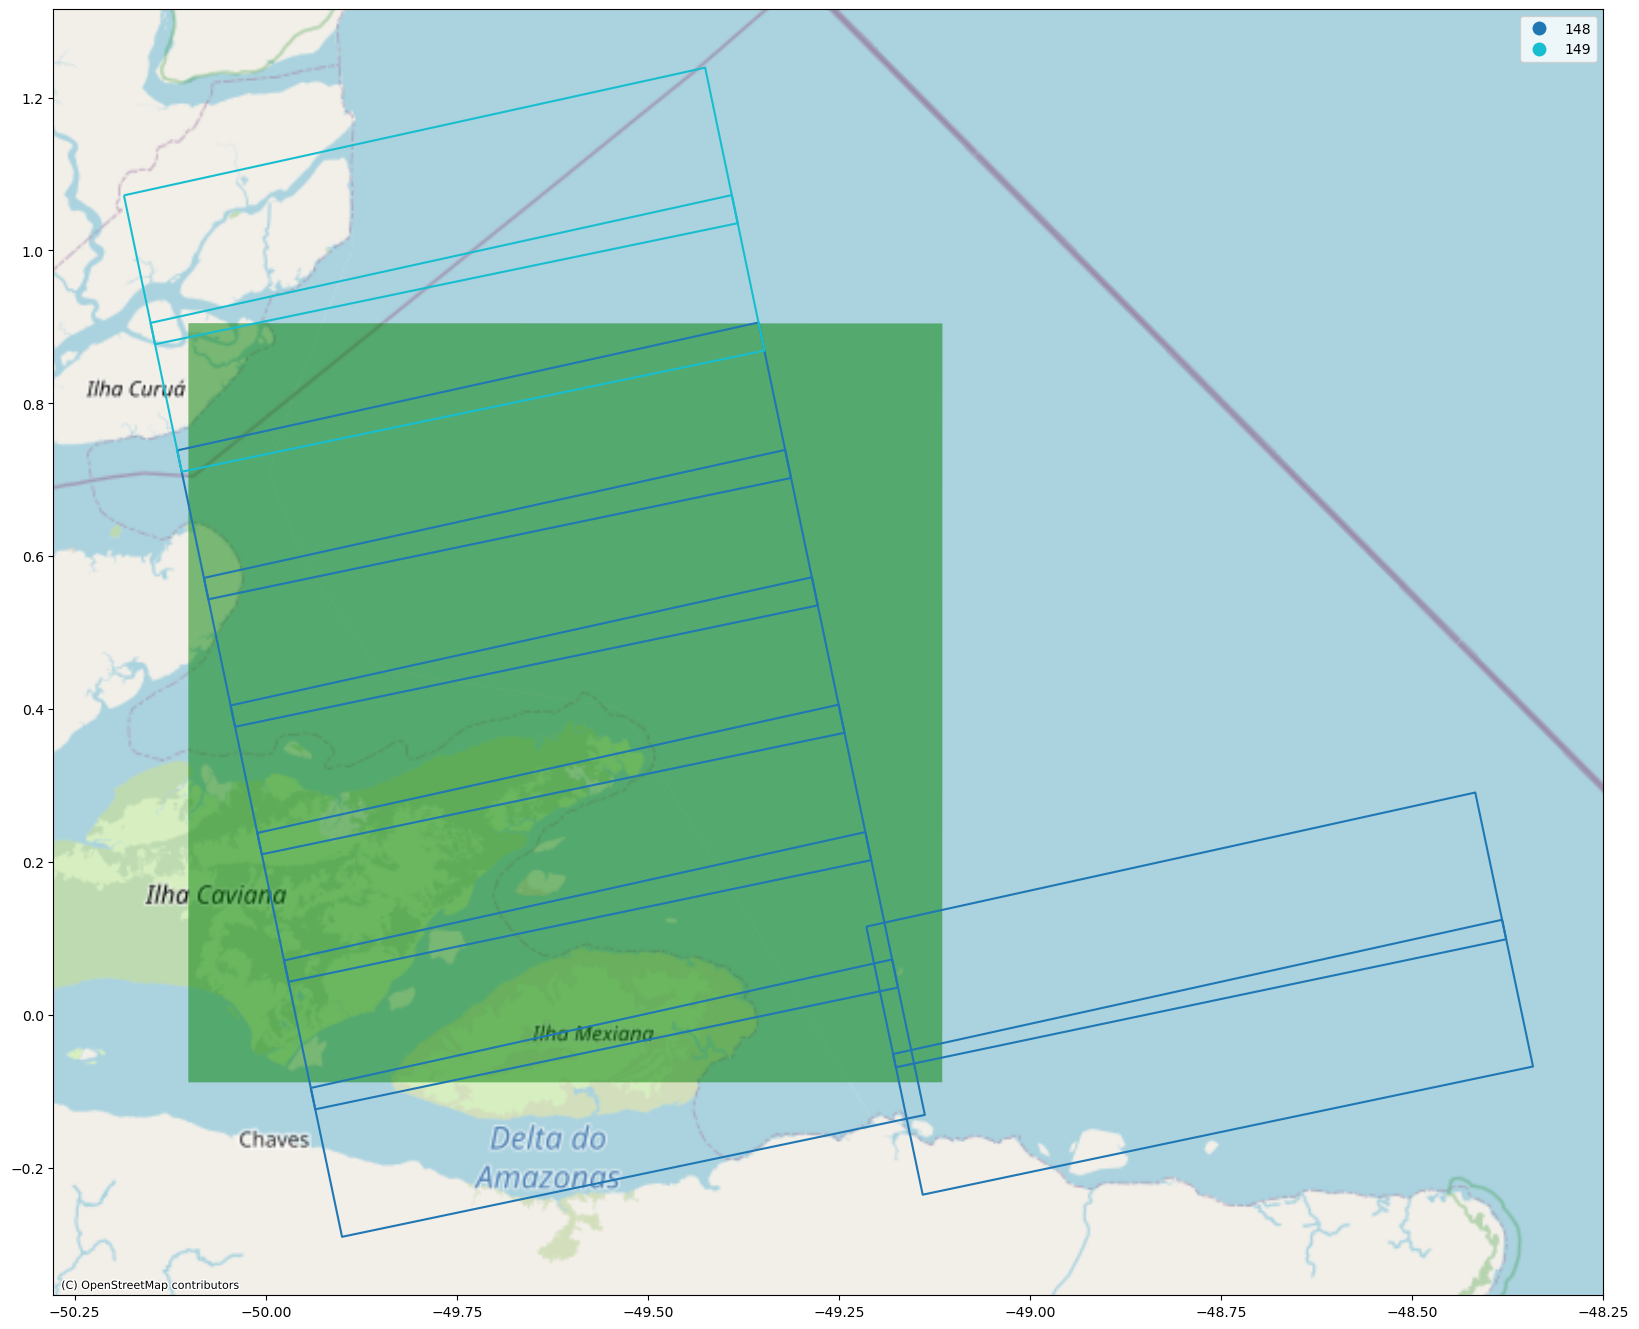

In [44]:
df_mrgs_burst_subset = df_mgrs_burst_f[df_mgrs_burst_f.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
burst_ids_subset = df_mrgs_burst_subset.jpl_burst_id.tolist()

df_mgrs_plot = df_mgrs[df_mgrs.mgrs_tile_id == mgrs_tile_id_near_eq].reset_index(drop=True)
df_burst_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_ids_subset)].reset_index(drop=True)
df_burst_plot.geometry = df_burst_plot.geometry.boundary
fig, ax = plt.subplots(dpi=100, figsize=(20, 20))
df_burst_plot = df_burst_plot[df_burst_plot.track_number.isin([148, 149])]

df_mgrs_plot.plot(alpha=.5, ax=ax, color='green')
df_burst_plot.plot(alpha=1, ax=ax, column='track_number', categorical=True, legend=True)

ctx.add_basemap(ax,
               crs=df_mgrs_plot.crs.to_string(),
               source=ctx.providers.OpenStreetMap.Mapnik
              )

# MGRS to Track Groups

In [45]:
def group_consecutive_tracks(tracks):
    tracks_sorted = sorted(list(set(tracks)))
    groups = []
    current_group = [tracks_sorted[0]]

    for track in tracks_sorted[1:]:
        if track - current_group[-1] <= 1:
            current_group.append(track)
        else:
            if len(current_group) > 2:
                raise ValueError('Too many tracks in group; should be at most 2')
            groups.append(current_group)
            current_group = [track]
    if current_group:
        if len(current_group) > 2:
            raise ValueError('Too many tracks in group; should be at most 2')
        groups.append(current_group)
    return groups

group_consecutive_tracks([1, 4, 5, 10, 15, 20, 21, 23])

[[1], [4, 5], [10], [15], [20, 21], [23]]

In [46]:
%%time

df_mgrs2track = df_mgrs_burst.groupby('mgrs_tile_id')['track_number'].apply(lambda tracks: list(tracks.unique())).reset_index()
df_mgrs2track.head()

CPU times: user 351 ms, sys: 10.5 ms, total: 361 ms
Wall time: 360 ms


,mgrs_tile_id,track_number
0,01FBE,"[154.0, 58.0, 131.0, 81.0]"
1,01FBF,"[58.0, 154.0, 131.0, 81.0]"
2,01GBH,"[81.0, 154.0, 29.0, 131.0]"
3,01GDM,"[110.0, 37.0, 58.0]"
4,01GEL,"[58.0, 110.0, 37.0, 160.0]"


In [47]:
df_mgrs2track = pd.merge( df_mgrs[['mgrs_tile_id', 'geometry']], df_mgrs2track)
df_mgrs2track = df_mgrs2track.rename(columns={'track_number': 'track_numbers_all'})
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[154.0, 58.0, 131.0, 81.0]"
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 154.0, 131.0, 81.0]"
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.9259, -179.5458...","[81.0, 154.0, 29.0, 131.0]"
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[110.0, 37.0, 58.0]"
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 110.0, 37.0, 160.0]"


In [48]:
df_bounds = df_mgrs2track.bounds
abs_lat = np.abs(df_bounds.miny.values, df_bounds.maxy.values)
df_mgrs2track['abs_lat'] = abs_lat

In [49]:
def track_grouping(row):
    track_numbers = row['track_numbers_all']
    abs_lat = row['abs_lat']
    if abs_lat < 70:
        track_groups = group_consecutive_tracks(track_numbers)
    else:
        track_groups = [[t] for t in sorted(track_numbers)]
    #track_group_strs = ['+'.join([str(s) for s in track_group]) for track_group in track_groups]
    #track_group_str = '_'.join(track_group_strs)
    return track_groups

df_mgrs2track['track_number_groups'] = df_mgrs2track.agg(track_grouping, axis=1)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[154.0, 58.0, 131.0, 81.0]",50.608678,"[[58.0], [81.0], [131.0], [154.0]]"
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 154.0, 131.0, 81.0]",49.710629,"[[58.0], [81.0], [131.0], [154.0]]"
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.9259, -179.5458...","[81.0, 154.0, 29.0, 131.0]",47.912929,"[[29.0], [81.0], [131.0], [154.0]]"
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[110.0, 37.0, 58.0]",44.341402,"[[37.0], [58.0], [110.0]]"
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 110.0, 37.0, 160.0]",45.241333,"[[37.0], [58.0], [110.0], [160.0]]"


In [50]:
def group_idxs(groups:list) -> dict:
    out = {track: group_idx for group_idx, group in enumerate(groups) for track in group}
    return out
    
df_mgrs2track['track_number_group_idxs'] = df_mgrs2track.track_number_groups.map(group_idxs)
df_mgrs2track['n_track_groups'] = df_mgrs2track.track_number_groups.map(len)
df_mgrs2track.head()

,mgrs_tile_id,geometry,track_numbers_all,abs_lat,track_number_groups,track_number_group_idxs,n_track_groups
0,01FBE,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688...","[154.0, 58.0, 131.0, 81.0]",50.608678,"[[58.0], [81.0], [131.0], [154.0]]","{58.0: 0, 81.0: 1, 131.0: 2, 154.0: 3}",4
1,01FBF,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638...","[58.0, 154.0, 131.0, 81.0]",49.710629,"[[58.0], [81.0], [131.0], [154.0]]","{58.0: 0, 81.0: 1, 131.0: 2, 154.0: 3}",4
2,01GBH,"MULTIPOLYGON (((-179.49865 -46.9259, -179.5458...","[81.0, 154.0, 29.0, 131.0]",47.912929,"[[29.0], [81.0], [131.0], [154.0]]","{29.0: 0, 81.0: 1, 131.0: 2, 154.0: 3}",4
3,01GDM,"POLYGON ((-178.23431 -43.34619, -178.25485 -44...","[110.0, 37.0, 58.0]",44.341402,"[[37.0], [58.0], [110.0]]","{37.0: 0, 58.0: 1, 110.0: 2}",3
4,01GEL,"POLYGON ((-177.00025 -44.25288, -177.00025 -45...","[58.0, 110.0, 37.0, 160.0]",45.241333,"[[37.0], [58.0], [110.0], [160.0]]","{37.0: 0, 58.0: 1, 110.0: 2, 160.0: 3}",4


In [51]:
df_mgrs2track.shape[0] == len(df_mgrs2track.mgrs_tile_id.unique())

True

In [52]:
mgrs2track_group = df_mgrs2track[['mgrs_tile_id', 'track_number_group_idxs']].set_index('mgrs_tile_id').to_dict()['track_number_group_idxs']
#mgrs2track_group

## Update The MGRS/Burst Table

In [53]:
df_mgrs_burst_f.head()

,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330470-IW2,ASCENDING,154.0
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW3,DESCENDING,58.0
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123814-IW3,DESCENDING,58.0
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330472-IW2,ASCENDING,154.0
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T131-280611-IW2,DESCENDING,131.0


In [54]:
%%time

def label_acquisition_group(row):
    mgrs_tile = row['mgrs_tile_id']
    track = row['track_number']
    track_group = mgrs2track_group[mgrs_tile][track]
    return track_group

df_mgrs_burst_f['acq_group_id_within_mgrs_tile'] = df_mgrs_burst_f.agg(label_acquisition_group, axis=1)
df_mgrs_burst_f.head()

CPU times: user 3.75 s, sys: 88.3 ms, total: 3.84 s
Wall time: 3.84 s


,mgrs_tile_id,utm_epsg,utm_wkt,geometry,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile
0,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330470-IW2,ASCENDING,154.0,3
1,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123815-IW3,DESCENDING,58.0,0
2,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T058-123814-IW3,DESCENDING,58.0,0
3,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T154-330472-IW2,ASCENDING,154.0,3
4,01FBE,32701,"MULTIPOLYGON(((199980 4500040,199980 4390240,3...","MULTIPOLYGON (((-179.63379 -49.62222, -179.688...",T131-280611-IW2,DESCENDING,131.0,2


In [55]:
df_mgrs_burst_f.shape

(1006812, 8)

# Counting The Number of Passes (i.e. Track Groups) Per MGRS Tile

Text(0, 0.5, 'Frequency')

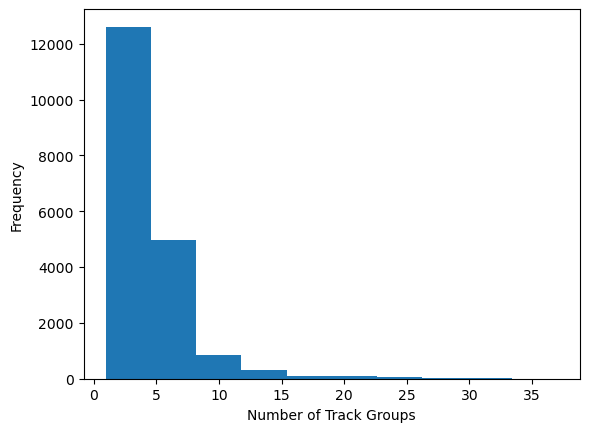

In [56]:
plt.hist(df_mgrs2track.n_track_groups.values)
plt.xlabel('Number of Track Groups')
plt.ylabel('Frequency')

# Calculating Area Per Pass in km${}^2$

In [57]:
df_burst_groups = pd.merge(df_burst_final_all, 
                           df_mgrs_burst_f[['jpl_burst_id', 'mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry']], 
                           on='jpl_burst_id', 
                           how='inner', 
                           suffixes=('', '_mgrs')
                          )

In [58]:
df_burst_groups.head()

,jpl_burst_id,orbit_pass,track_number,geometry,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry_mgrs
0,T001-000025-IW3,ASCENDING,1,"MULTIPOLYGON Z (((4.02659 5.18854 0, 4.38755 5...",31NFG,0,"POLYGON ((3.90412 6.33225, 3.90253 5.33909, 4...."
1,T001-000027-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.95778 5.52153 0, 4.31898 5...",31NFG,0,"POLYGON ((3.90412 6.33225, 3.90253 5.33909, 4...."
2,T001-000030-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.85573 6.02123 0, 4.21726 6...",31NEH,0,"POLYGON ((2.99982 7.23783, 2.99982 6.24457, 3...."
3,T001-000030-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.85573 6.02123 0, 4.21726 6...",31NFG,0,"POLYGON ((3.90412 6.33225, 3.90253 5.33909, 4...."
4,T001-000030-IW3,ASCENDING,1,"MULTIPOLYGON Z (((3.85573 6.02123 0, 4.21726 6...",31NFH,0,"POLYGON ((3.90581 7.23693, 3.90396 6.24379, 4...."


In [59]:
%%time

df_burst_groups_d = df_burst_groups.dissolve(by=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'], aggfunc='first').reset_index(drop=False)
df_burst_groups_d.head()

CPU times: user 18.2 s, sys: 151 ms, total: 18.3 s
Wall time: 18.4 s


,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,jpl_burst_id,orbit_pass,track_number,geometry_mgrs
0,01FBE,0,"POLYGON Z ((179.52578 -50.17351 0, 178.99558 -...",T058-123813-IW3,DESCENDING,58,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
1,01FBE,1,"MULTIPOLYGON Z (((179.25797 -50.1926 0, 179.17...",T081-173674-IW1,ASCENDING,81,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
2,01FBE,2,"MULTIPOLYGON Z (((-179.95322 -50.15224 0, -179...",T131-280610-IW2,DESCENDING,131,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
3,01FBE,3,"MULTIPOLYGON Z (((178.41322 -50.12918 0, 179.0...",T154-330470-IW2,ASCENDING,154,"MULTIPOLYGON (((-179.63379 -49.62222, -179.688..."
4,01FBF,0,"POLYGON Z ((179.73618 -49.82955 0, 179.72794 -...",T058-123813-IW3,DESCENDING,58,"MULTIPOLYGON (((-179.58653 -48.72398, -179.638..."


In [60]:
df_burst_groups_d = df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'geometry', 'geometry_mgrs']]

<Axes: >

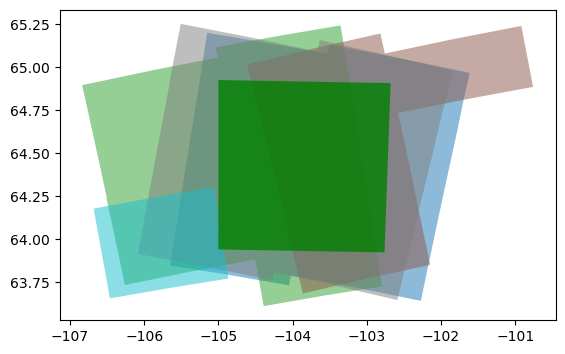

In [61]:
fig, ax = plt.subplots()

K = 10004
df_t = df_burst_groups_d.iloc[K:K + 5].reset_index()
df_t.plot(column='acq_group_id_within_mgrs_tile', categorical=True, ax=ax, alpha=.5)
df_mgrs[df_mgrs.mgrs_tile_id.isin(df_t.mgrs_tile_id.unique().tolist())].plot(ax=ax, alpha=.8, color='green')

In [62]:
geos_l = df_burst_groups_d.geometry.tolist()[:]
geos_r = df_burst_groups_d.geometry_mgrs.tolist()[:]

100%|████████████████| 93969/93969 [00:00<00:00, 10067293.81it/s]


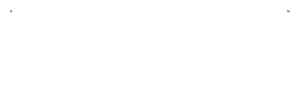

In [63]:
import shapely
from multiprocessing import Pool
from tqdm import tqdm
from itertools import starmap
from functools import partial


n_jobs = 5
geos_l_r_zipped = list(zip(geos_l, geos_r))


with Pool(processes=n_jobs) as pool:
    geos_intersected = list(tqdm(pool.starmap(shapely.intersection, geos_l_r_zipped, chunksize=1),
                                 total=len(geos_l_r_zipped)))

geos_intersected[10]

In [64]:
df_burst_groups_area = gpd.GeoDataFrame(df_burst_groups_d[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']],
                                        geometry=geos_intersected,
                                        crs=CRS.from_epsg(4326))
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry
0,01FBE,0,"POLYGON Z ((178.99558 -50.04245 0, 178.8128 -4..."
1,01FBE,1,"MULTIPOLYGON Z (((179.17281 -50.03208 0, 179.1..."
2,01FBE,2,"MULTIPOLYGON Z (((-179.96086 -50.16664 0, -179..."
3,01FBE,3,"MULTIPOLYGON Z (((179.0248 -49.98076 0, 179.59..."
4,01FBF,0,"POLYGON Z ((179.30588 -49.53695 0, 179.829 -49..."


In [65]:
df_burst_groups_area['area_km2'] = df_burst_groups_area.to_crs('6933')['geometry'].map(lambda p: p.area / 10**6)
df_burst_groups_area.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,geometry,area_km2
0,01FBE,0,"POLYGON Z ((178.99558 -50.04245 0, 178.8128 -4...",3491.290935
1,01FBE,1,"MULTIPOLYGON Z (((179.17281 -50.03208 0, 179.1...",3572.193195
2,01FBE,2,"MULTIPOLYGON Z (((-179.96086 -50.16664 0, -179...",4042.012652
3,01FBE,3,"MULTIPOLYGON Z (((179.0248 -49.98076 0, 179.59...",2468.555533
4,01FBF,0,"POLYGON Z ((179.30588 -49.53695 0, 179.829 -49...",1062.866416


In [66]:
df_mgrs_burst_with_area = pd.merge(df_mgrs_burst_f, 
                                   df_burst_groups_area[['mgrs_tile_id', 'acq_group_id_within_mgrs_tile', 'area_km2']],
                                   how='left',
                                   on=['mgrs_tile_id', 'acq_group_id_within_mgrs_tile'])
assert df_mgrs_burst_with_area.shape[0] == df_mgrs_burst_f.shape[0]
df_mgrs_burst_with_area.rename(columns={'area_km2': 'area_per_acq_group_km2'}, inplace=True)
df_mgrs_burst_with_area = df_mgrs_burst_with_area.drop(columns=['utm_epsg', 'utm_wkt', 'geometry'])
df_mgrs_burst_with_area.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2
0,01FBE,T154-330470-IW2,ASCENDING,154.0,3,2468.555533
1,01FBE,T058-123815-IW3,DESCENDING,58.0,0,3491.290935
2,01FBE,T058-123814-IW3,DESCENDING,58.0,0,3491.290935
3,01FBE,T154-330472-IW2,ASCENDING,154.0,3,2468.555533
4,01FBE,T131-280611-IW2,DESCENDING,131.0,2,4042.012652


In [135]:
ind = (df_mgrs_burst_with_area.area_per_acq_group_km2.values < 250)
(ind).sum()

np.int64(12009)

In [136]:
df_mgrs_burst_with_area_small = df_mgrs_burst_with_area[ind].reset_index()
df_mgrs_burst_with_area_small = df_mgrs_burst_with_area_small.sort_values(by='area_per_acq_group_km2', ascending=False)

249.17510715980177

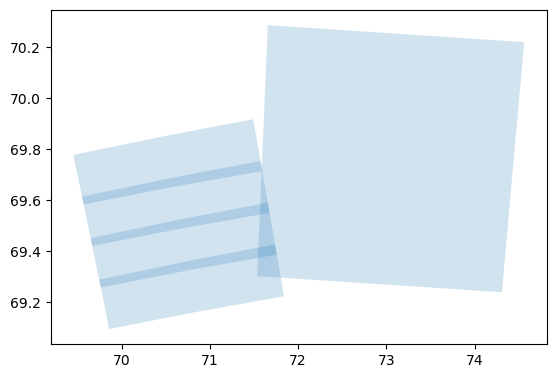

In [137]:
K = 0

sample = df_mgrs_burst_with_area_small.iloc[K]
#sample = df_mgrs_burst_with_area_small[df_mgrs_burst_with_area_small.jpl_burst_id == 'T146-311676-IW3'].reset_index(drop=True).iloc[0]
df_mgrs_tile = df_mgrs[df_mgrs.mgrs_tile_id == sample.mgrs_tile_id]

ind0 = (df_mgrs_burst_f.mgrs_tile_id == sample.mgrs_tile_id)
ind1 = (df_mgrs_burst_f.acq_group_id_within_mgrs_tile == sample.acq_group_id_within_mgrs_tile)
burst_over_tiles = df_mgrs_burst_f[ind0 & ind1].jpl_burst_id.tolist()
df_bursts_over_plot = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(burst_over_tiles)]

fig, ax = plt.subplots()
df_bursts_over_plot.plot(ax=ax, alpha=.2)
df_mgrs_tile.plot(ax=ax, alpha=.2)

m_geo = df_mgrs_tile.to_crs(6933).geometry.tolist()[0]
b_geo = df_bursts_over_plot.to_crs(6933).geometry.union_all()

shapely.intersection(m_geo, b_geo).area / 10**6

## Append Burst Count Per MGRS Tile and Data-take

In [116]:
group = ['mgrs_tile_id', 'acq_group_id_within_mgrs_tile']
df_counts = df_mgrs_burst_with_area.groupby(group).size().reset_index(name='n_bursts_per_acq_group')
df_counts.head()

,mgrs_tile_id,acq_group_id_within_mgrs_tile,n_bursts_per_acq_group
0,01FBE,0,3
1,01FBE,1,2
2,01FBE,2,4
3,01FBE,3,3
4,01FBF,0,2


In [117]:
df_mgrs_burst_filtered_with_counts = pd.merge(df_mgrs_burst_with_area, df_counts, how='left', on=group)
df_mgrs_burst_filtered_with_counts.head()

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2,n_bursts_per_acq_group
0,01FBE,T154-330470-IW2,ASCENDING,154.0,3,2468.555533,3
1,01FBE,T058-123815-IW3,DESCENDING,58.0,0,3491.290935,3
2,01FBE,T058-123814-IW3,DESCENDING,58.0,0,3491.290935,3
3,01FBE,T154-330472-IW2,ASCENDING,154.0,3,2468.555533,3
4,01FBE,T131-280611-IW2,DESCENDING,131.0,2,4042.012652,4


# Filtering by Area and number of bursts

In [118]:
ind_area = df_mgrs_burst_filtered_with_counts.area_per_acq_group_km2 > 100
ind_burst = df_mgrs_burst_filtered_with_counts.n_bursts_per_acq_group >= 1

df_mgrs_burst_final = df_mgrs_burst_filtered_with_counts[ind_area & ind_burst].reset_index(drop=True)
df_mgrs_burst_final.shape

(1000609, 7)

In [119]:
df_mgrs_burst_final.track_number = df_mgrs_burst_final.track_number.astype(int)
df_mgrs_burst_final.area_per_acq_group_km2 = df_mgrs_burst_final.area_per_acq_group_km2.astype(int)

df_mgrs_burst_final = df_mgrs_burst_final.sort_values(by=['mgrs_tile_id', 'jpl_burst_id', 'acq_group_id_within_mgrs_tile']).reset_index(drop=True)
df_mgrs_burst_final.head(10)

,mgrs_tile_id,jpl_burst_id,orbit_pass,track_number,acq_group_id_within_mgrs_tile,area_per_acq_group_km2,n_bursts_per_acq_group
0,01FBE,T058-123813-IW3,DESCENDING,58,0,3491,3
1,01FBE,T058-123814-IW3,DESCENDING,58,0,3491,3
2,01FBE,T058-123815-IW3,DESCENDING,58,0,3491,3
3,01FBE,T081-173674-IW1,ASCENDING,81,1,3572,2
4,01FBE,T081-173675-IW1,ASCENDING,81,1,3572,2
5,01FBE,T131-280610-IW2,DESCENDING,131,2,4042,4
6,01FBE,T131-280611-IW1,DESCENDING,131,2,4042,4
7,01FBE,T131-280611-IW2,DESCENDING,131,2,4042,4
8,01FBE,T131-280612-IW1,DESCENDING,131,2,4042,4
9,01FBE,T154-330470-IW2,ASCENDING,154,3,2468,3


In [120]:
df_mgrs_burst_final.to_parquet('mgrs_burst_lookup_table.parquet', compression='zstd')

# Serializing Burst data

In [121]:
from shapely.geometry import Polygon, MultiPolygon

def update_geometry_low_tech(geo):
    if isinstance(geo, Polygon):
        return geo
    elif isinstance(geo, MultiPolygon):
        geoms = list(geo.geoms)
        if len(geoms) == 1:
            geo = geoms[0]
        return geo
    else:
        raise ValueError('weird geometry!')

In [122]:
dist_s1_bursts = df_mgrs_burst_final.jpl_burst_id.unique().tolist()
df_burst_final_dist_s1 = df_burst_final_all[df_burst_final_all.jpl_burst_id.isin(dist_s1_bursts)][['jpl_burst_id', 'geometry']].reset_index(drop=True)
df_burst_final_dist_s1['geometry'] = df_burst_final_dist_s1['geometry'].map(update_geometry_low_tech)
df_burst_final_dist_s1['geometry'] = df_burst_final_dist_s1['geometry'].force_2d()
print(df_burst_final_dist_s1.shape)
df_burst_final_dist_s1.head()

(319554, 2)


,jpl_burst_id,geometry
0,T001-000025-IW3,"POLYGON ((4.02659 5.18854, 4.38755 5.26068, 4...."
1,T001-000027-IW3,"POLYGON ((3.95778 5.52153, 4.31898 5.5935, 4.6..."
2,T001-000030-IW3,"POLYGON ((3.85573 6.02123, 4.21726 6.09294, 4...."
3,T001-000031-IW3,"POLYGON ((3.82176 6.1878, 4.18341 6.25942, 4.5..."
4,T001-000032-IW2,"POLYGON ((3.01846 6.14155, 3.43161 6.22449, 3...."


In [123]:
df_burst_final_dist_s1.to_parquet('jpl_burst_geo.parquet', compression='zstd')

In [124]:
df_burst_final_dist_s1.shape

(319554, 2)

# MGRS finalization

In [125]:
final_mgrs_tiles = df_mgrs_burst_final.mgrs_tile_id.unique().tolist()

In [126]:
df_mgrs_final = df_mgrs_dist_hls[df_mgrs_dist_hls.mgrs_tile_id.isin(final_mgrs_tiles)].reset_index(drop=True)

In [127]:
df_mgrs_final.to_parquet('mgrs_hls.parquet', compression='zstd')

In [128]:
df_mgrs_final.shape[0], df_mgrs_dist_hls.shape[0]

(19002, 19043)

In [129]:
blacklisted_mgrs_tiles = [mid for mid in df_mgrs_dist_hls.mgrs_tile_id.tolist() 
                          if mid not in df_mgrs_final.mgrs_tile_id.tolist()]

In [130]:
len(blacklisted_mgrs_tiles)

41

In [131]:
sorted(blacklisted_mgrs_tiles)

['02RQN',
 '02RRN',
 '05LNJ',
 '15DWD',
 '15DXD',
 '17NQE',
 '17PPR',
 '23EMN',
 '23EMP',
 '23ENN',
 '24KTU',
 '30NWK',
 '36JZT',
 '37GCH',
 '37GCJ',
 '37GDH',
 '37GDJ',
 '37KES',
 '47NRJ',
 '49NHJ',
 '49PEK',
 '49PFK',
 '49PGK',
 '49PGL',
 '49PHK',
 '49PHL',
 '50KPF',
 '50KQF',
 '50MNB',
 '50PKQ',
 '50PKR',
 '50PLQ',
 '50PLR',
 '50PRQ',
 '52MCU',
 '52MCV',
 '53QPC',
 '54RXR',
 '55KEB',
 '55KFA',
 '57XVF']